In [1]:
!pip install river
!pip install deepctr-torch

In [2]:
import numpy as np
np.float = float
from river.drift import ADWIN
import random
import os
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder

In [4]:
#loading the data
reviews = pd.read_json("/Users/jasperbruin/Documents/driftwatch/LAB experiments/datasets/CDs_and_Vinyl.jsonl", lines=True)

In [5]:
# Preparing the data
# Filter out reviews with a rating of 3
reviews = reviews[reviews["rating"] != 3]
print("After filtering out ratings equal to 3:")
print(reviews.head())

# Keep only reviews after the timestamp "2015-01-01"
reviews = reviews[reviews["timestamp"] > "2015-01-01"]
print("\nAfter filtering reviews with timestamp > '2015-01-01':")
print(reviews.head())

# Extract year, month, and day from the timestamp
reviews["year"] = reviews["timestamp"].apply(lambda x: x.year)
reviews["month"] = reviews["timestamp"].apply(lambda x: x.month)
reviews["day"] = reviews["timestamp"].apply(lambda x: x.day)
print("\nAfter extracting year, month, and day from the timestamp:")
print(reviews.head())


After filtering out ratings equal to 3:
   rating                             title  \
0       5                        Five Stars   
1       5                        Five Stars   
4       5                 Wonderful melding   
5       5  Magnificent movie & music score!   
6       5                        Five Stars   

                                                text images        asin  \
0                                           LOVE IT!     []  B002MW50JA   
1                                             LOVE!!     []  B008XNPN0S   
4  Simply great album. One of the best. Marvelous...     []  B00013YRQY   
5  The sound is incredibly beautiful. If you like...     []  B07Z76Y18X   
6                                   beautiful music!     []  B00004NKAK   

  parent_asin                       user_id               timestamp  \
0  B002MW50JA  AGKASBHYZPGTEPO6LWZPVJWB2BVA 2016-01-13 02:06:17.000   
1  B008XNPN0S  AGKASBHYZPGTEPO6LWZPVJWB2BVA 2016-01-13 02:06:04.000   
4  B00013YRQY

In [6]:
# Create reference dataframe
reference_data = reviews[reviews["timestamp"] > "2015-01-01"]
print("Reference data after filtering timestamp > '2015-01-01':")
print(reference_data.head())

reference_data = reference_data[reference_data["timestamp"] < "2019-01-01"]
print("\nReference data after filtering timestamp < '2019-01-01':")
print(reference_data.head())

# Create evaluation dataframe
evaluation_data = reviews[reviews["timestamp"] >= "2019-01-01"]
print("\nEvaluation data after filtering timestamp >= '2019-01-01':")
print(evaluation_data.head())

# Set index and sort evaluation data
evaluation_data = evaluation_data.set_index(evaluation_data["timestamp"])
evaluation_data.sort_index(inplace=True)
print("\nEvaluation data after setting index and sorting by timestamp:")
print(evaluation_data.head())


Reference data after filtering timestamp > '2015-01-01':
   rating                             title  \
0       5                        Five Stars   
1       5                        Five Stars   
4       5                 Wonderful melding   
5       5  Magnificent movie & music score!   
6       5                        Five Stars   

                                                text images        asin  \
0                                           LOVE IT!     []  B002MW50JA   
1                                             LOVE!!     []  B008XNPN0S   
4  Simply great album. One of the best. Marvelous...     []  B00013YRQY   
5  The sound is incredibly beautiful. If you like...     []  B07Z76Y18X   
6                                   beautiful music!     []  B00004NKAK   

  parent_asin                       user_id               timestamp  \
0  B002MW50JA  AGKASBHYZPGTEPO6LWZPVJWB2BVA 2016-01-13 02:06:17.000   
1  B008XNPN0S  AGKASBHYZPGTEPO6LWZPVJWB2BVA 2016-01-13 02:06:04.000

In [7]:
# remove products that appear after ref
evaluation_data_with_old_products = evaluation_data[evaluation_data["parent_asin"].isin(reference_data["parent_asin"])]

In [8]:
#encode features in the reviews for use in ml model
sparse_features = ["parent_asin", "user_id","year","month","day"]
for feat in sparse_features:
        lbe = LabelEncoder()
        reviews[feat] = lbe.fit_transform(reviews[feat])

In [9]:
def create_matrix(df):
	
	N = len(df['user_id'].unique())
	M = len(df['product_id'].unique())
	
	# Map Ids to indices
	user_mapper = dict(zip(np.unique(df["user_id"]), list(range(N))))
	product_mapper = dict(zip(np.unique(df["product_id"]), list(range(M))))
	
	# Map indices to IDs
	user_inv_mapper = dict(zip(list(range(N)), np.unique(df["user_id"])))
	product_inv_mapper = dict(zip(list(range(M)), np.unique(df["product_id"])))
	
	user_index = [user_mapper[i] for i in df['user_id']]
	product_index = [product_mapper[i] for i in df['product_id']]

	X = csr_matrix((df["rating"], (product_index, user_index)), shape=(M, N))
	
	return X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper

In [10]:
#rename for use in function
reference_data["product_id"] = reference_data["parent_asin"]

In [11]:
X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper = create_matrix(reference_data)

In [12]:
#train ml model
kNN = NearestNeighbors(n_neighbors=5, algorithm="brute", metric='cosine')
kNN.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine')

In [13]:
def find_similar_products(product_id, X, k, metric='cosine', show_distance=False):

  neighbour_ids = []

  product_ind = product_mapper[product_id]
  product_vec = X[product_ind]
  k+=1
  product_vec = product_vec.reshape(1,-1)
  neighbour = kNN.kneighbors(product_vec, return_distance=show_distance)
  for i in range(0,k):
    n = neighbour.item(i)
    neighbour_ids.append(product_inv_mapper[n])
  neighbour_ids.pop(0)
  return neighbour_ids

In [14]:
#sample reviews from products
# sampled = evaluation_data_with_old_products.sample(100)

sampled = evaluation_data_with_old_products.sample(10000)

In [15]:
#save sample
sampled.reset_index(inplace=True,drop=True)
sampled.to_json("sampled_products.json")

In [16]:
#store the predictions of the recommendation system (takes a long time)
preds = []
for i in range(len(sampled)):
    preds.append(find_similar_products(sampled["parent_asin"].values[i],X,4))

In [17]:
sampled.sort_index(inplace = True)

In [18]:
#store the recommendations in dataframe
sampled["recommendation"] = preds

In [19]:
reviews_copy = pd.read_json("/Users/jasperbruin/Documents/driftwatch/LAB experiments/datasets/CDs_and_Vinyl.jsonl", lines=True)

In [20]:
#ensure same strutcture as ctr-predictor training data
reviews_copy = reviews_copy[reviews_copy["rating"] != 3]
reviews_copy = reviews_copy[reviews_copy["timestamp"] > "2015-01-01"]

In [21]:
# create a mapper for the ctr-predictor
music_mapper = dict(zip(reviews_copy["parent_asin"].unique(), reviews["parent_asin"].unique()))

In [22]:
# create a mapper for the ctr-predictor
music_user_mapper = dict(zip(reviews_copy["user_id"].unique(), reviews["user_id"].unique()))

In [24]:
# load the ctr-predictor
model = torch.load("/Users/jasperbruin/Documents/driftwatch/LAB experiments/models/model_formatted_music_v2_cpu")

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_99362/410439767.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/Users/jasperbruin/Documen

In [25]:
# calculate click-through-rate for the recommendations
def mean_predicted_ctr():
    res = []
    for i in range(len(sampled)):
        temp = []
        for j in range(len(sampled["recommendation"][i])):
            temp.append(model.predict({"parent_asin": pd.Series(music_mapper[sampled["recommendation"][i][j]]),"user_id": pd.Series(music_user_mapper[sampled["user_id"][i]]), "year": pd.Series(sampled["year"][i] - 2015), "month": pd.Series(sampled["month"][i] - 1), "day": pd.Series(sampled["day"][i] - 1)}))
        res.append(temp)    
    return res

In [26]:
ctr_list = mean_predicted_ctr()

In [27]:
ctr_list

[[array([[0.61850995]]),
  array([[0.00912637]]),
  array([[0.30987632]]),
  array([[0.86105967]])],
 [array([[0.95922339]]),
  array([[0.93523103]]),
  array([[0.95839912]]),
  array([[0.99999034]])],
 [array([[0.43032351]]),
  array([[0.43032351]]),
  array([[0.43032351]]),
  array([[0.43319479]])],
 [array([[0.9999994]]),
  array([[0.99908912]]),
  array([[0.99983752]]),
  array([[0.99709153]])],
 [array([[0.99972469]]),
  array([[0.99993348]]),
  array([[0.99970204]]),
  array([[0.99767369]])],
 [array([[0.9999938]]),
  array([[0.99992704]]),
  array([[0.99995172]]),
  array([[0.99999475]])],
 [array([[0.65198731]]),
  array([[0.55234236]]),
  array([[0.99745077]]),
  array([[0.65756851]])],
 [array([[0.83744711]]),
  array([[0.91075736]]),
  array([[0.58238173]]),
  array([[0.77848011]])],
 [array([[0.9999522]]),
  array([[0.99999726]]),
  array([[0.99972934]]),
  array([[0.99997926]])],
 [array([[0.56702042]]),
  array([[0.62928241]]),
  array([[0.95768249]]),
  array([[0.5885755

In [28]:
means = []
for i in range(len(ctr_list)):
    means.append(np.mean(ctr_list[i]))

In [29]:
np.mean(means)

0.8538121379697248

In [30]:
series_means = pd.Series(means, index=sampled["timestamp"])
series_means = series_means.sort_index()

In [31]:
rolling_means = series_means.rolling("30D").mean()

<Axes: xlabel='timestamp'>

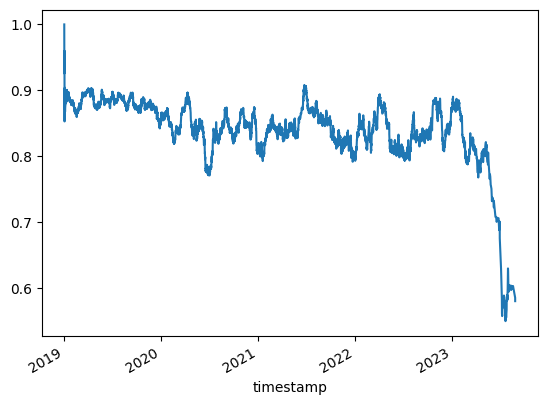

In [32]:
rolling_means.plot()

In [6]:
# create labels for the drift-detectors
correct_recommendations = []
for i in range(len(ctr_list)):
    for j in range(4):
        correct_recommendations.append(random.choices([0,1],weights=[1-ctr_list[i][j][0][0],ctr_list[i][j][0][0]])[0])

NameError: name 'ctr_list' is not defined

In [34]:
#testing the different erb-detectors

In [35]:
adwin = ADWIN()
entry_number = 0
entries = []

for i in range(len(correct_recommendations)):
    # Update the detector with the current value
    adwin.update(correct_recommendations[i])
    
    # Check if drift is detected
    if adwin.drift_detected:
        print(
            f"Change detected at index {i}, value: {correct_recommendations[i]}, entry: {entry_number}"
        )
        entries.append(entry_number)
    
    # Update entry number every 4 iterations
    if i % 4 == 3:
        entry_number += 1


In [36]:
for i in entries:
    print(sampled["timestamp"][i])

In [37]:
np.datetime64("2019-06-01") +  296 * np.timedelta64(1, 'D')

numpy.datetime64('2020-03-23')

In [38]:
np.datetime64('2020-07-07') - np.datetime64('2020-03-23')

numpy.timedelta64(106,'D')

In [39]:
counter = 0
for i in entries:
    print(sampled["timestamp"][i])
    if np.datetime64(sampled["timestamp"][i]) >= np.datetime64('2020-03-23'):
        counter = counter + 1

In [40]:
counter

0

In [4]:
import numpy as np

class SW_UCB_DriftDetector:
    def __init__(self, window_size=100, confidence=1.96):
        """
        Initializes the SW-UCB Drift Detector.

        Parameters:
        - window_size: Number of recent observations to maintain.
        - confidence: Confidence parameter for UCB (e.g., 1.96 for 95% confidence).
        """
        self.window_size = window_size
        self.confidence = confidence
        self.window = []
        self.drift_points = []

    def update(self, value, index):
        """
        Updates the sliding window with a new value and checks for drift.

        Parameters:
        - value: The new observation.
        - index: The index (e.g., timestamp or position) of the observation.

        Returns:
        - drift_detected: Boolean indicating if a drift was detected.
        """
        self.window.append(value)
        if len(self.window) > self.window_size:
            self.window.pop(0)
        
        drift_detected = False
        if len(self.window) == self.window_size:
            mean = np.mean(self.window)
            std = np.std(self.window)
            ucb = mean + self.confidence * (std / np.sqrt(self.window_size))
            if value > ucb:
                drift_detected = True
                self.drift_points.append(index)
        
        return drift_detected

    def get_drift_points(self):
        """
        Returns the list of detected drift points.

        Returns:
        - drift_points: List of indices where drift was detected.
        """
        return self.drift_points


In [5]:
from datetime import datetime

sw_ucb = SW_UCB_DriftDetector(window_size=100, confidence=1.96)

drift_indices = []
for i, label in enumerate(correct_recommendations):
    drift = sw_ucb.update(label, i)
    if drift:
        drift_indices.append(i)
        print(f"Drift detected at index: {i}")

drift_timestamps = sampled.index[drift_indices]

plt.figure(figsize=(20, 10))
plt.plot(series_means, label='Mean CTR (30D Rolling)')
for ts in drift_timestamps:
    plt.axvline(ts, color='r', linestyle='--', alpha=0.7)
plt.legend(['Mean CTR', 'Drift'])
plt.title('CTR Drift Detection using SW-UCB')
plt.xlabel('Date')
plt.ylabel('CTR')
plt.show()

print("Detected drifts at the following timestamps:")
for ts in drift_timestamps:
    print(ts)

NameError: name 'correct_recommendations' is not defined